In [3]:
import pandas as pd
import numpy as np


otodom = pd.read_csv('Otodom_Flat_Listings.csv')

# Sprawdzamy nazwy kolumn i typy danych
print(otodom.info())
otodom.head()

<class 'pandas.DataFrame'>
RangeIndex: 2807 entries, 0 to 2806
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Title                   2807 non-null   str    
 1   Price                   2664 non-null   float64
 2   Location                2806 non-null   str    
 3   Surface                 2807 non-null   float64
 4   Number_of_Rooms         2807 non-null   str    
 5   Floor                   2743 non-null   str    
 6   Finishing_Condition     2229 non-null   str    
 7   Heating                 2060 non-null   str    
 8   Parking_Space           1478 non-null   str    
 9   Balcony_Garden_Terrace  2102 non-null   str    
 10  Link                    2807 non-null   str    
 11  Voivodeship             2806 non-null   str    
 12  City                    2806 non-null   str    
dtypes: float64(2), str(11)
memory usage: 285.2 KB
None


,Title,Price,Location,Surface,Number_of_Rooms,Floor,Finishing_Condition,Heating,Parking_Space,Balcony_Garden_Terrace,Link,Voivodeship,City
0,2 pokoje 47m2 po remoncie + garderoba + balkon,415000.0,"ul. Marysińska, Stare Bałuty, Bałuty, Łódź, łó...",47.0,2,NaN,do zamieszkania,miejskie,garaż/miejsce parkingowe,balkon,https://www.otodom.pl/pl/oferta/2-pokoje-47m2-...,Łódzkie,Łódź
1,Właściciel- Ludwiki DD - WIDOK NA ZIELEŃ - 2x gar,2499000.0,"ul. Ludwiki, Czyste, Wola, Warszawa, mazowieckie",105.0,4,2/8,do wykończenia,miejskie,garaż/miejsce parkingowe,balkon,https://www.otodom.pl/pl/oferta/wlasciciel-lud...,Mazowieckie,Warszawa
2,"Sprzedam mieszkanie 60m2, 2 balkony, garderoba",649000.0,"ul. Londyńska, Gorzów Wielkopolski, lubuskie",60.0,3,4/4,do zamieszkania,miejskie,NaN,"balkon, taras",https://www.otodom.pl/pl/oferta/sprzedam-miesz...,Lubuskie,Gorzów Wielkopolski
3,"Wyjątkowy, duży apartament z antresolą",2108000.0,"Mrzeżyno, Trzebiatów, gryficki, zachodniopomor...",78.3,3,4/4,do wykończenia,NaN,garaż/miejsce parkingowe,NaN,https://www.otodom.pl/pl/oferta/wyjatkowy-duzy...,Zachodniopomorskie,gryficki
4,"2/3-pok. 49,2 m2 w samym sercu Koszalina - Kuncer",450180.0,"ul. Bartosza Głowackiego, Koszalin, zachodniop...",49.2,2,2/3,do zamieszkania,miejskie,garaż/miejsce parkingowe,balkon,https://www.otodom.pl/pl/oferta/2-3-pok-49-2-m...,Zachodniopomorskie,Koszalin


In [4]:
if 'Price' in otodom.columns:
    otodom['Price_clean'] = pd.to_numeric(otodom['Price'], errors='coerce')

otodom_clean = otodom.dropna(subset=['Price_clean'])

In [6]:
import mystats
import importlib
importlib.reload(mystats)

ceny = otodom_clean['Price_clean'].tolist()

mediana_cen = mystats.median(ceny)
srednia_uc_cen = mystats.trimmed_mean(ceny, 0.1)

print(f"Mediana cen mieszkań: {mediana_cen:,.2f} zł")
print(f"Średnia ucinana cen (p=0.1): {srednia_uc_cen:,.2f} zł")

Mediana cen mieszkań: 573,000.00 zł
Średnia ucinana cen (p=0.1): 596,380.16 zł


In [7]:
import mystats
mediana_cen = mystats.median(ceny)
print(f"Mediana: {mediana_cen}")

Mediana: 573000.0


In [9]:
# --- ZADANIE 1 ---

kompletnosc = otodom.notnull().mean()
print("Kompletność poszczególnych cech:")
print(kompletnosc)

poprawnosc_ceny = (otodom['Price'].dropna() > 0).mean()
print(f"\nPoprawność danych w kolumnie Price: {poprawnosc_ceny * 100:.2f}%")

jakosc_danych = (kompletnosc.mean() + poprawnosc_ceny) / 2
print(f"\nZbiorcza metryka jakości danych: {jakosc_danych:.4f}")

Kompletność poszczególnych cech:
Title                     1.000000
Price                     0.949056
Location                  0.999644
Surface                   1.000000
Number_of_Rooms           1.000000
Floor                     0.977200
Finishing_Condition       0.794086
Heating                   0.733880
Parking_Space             0.526541
Balcony_Garden_Terrace    0.748842
Link                      1.000000
Voivodeship               0.999644
City                      0.999644
Price_clean               0.949056
dtype: float64

Poprawność danych w kolumnie Price: 100.00%

Zbiorcza metryka jakości danych: 0.9528


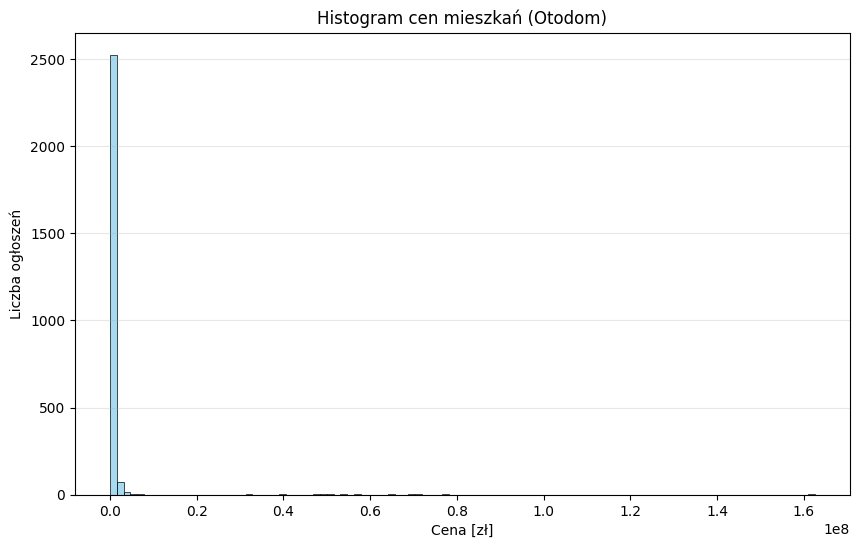

In [11]:
# --- ZADANIE 2 ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(otodom['Price'].dropna(), kde=False, color='skyblue')

plt.title('Histogram cen mieszkań (Otodom)')
plt.xlabel('Cena [zł]')
plt.ylabel('Liczba ogłoszeń')
plt.grid(axis='y', alpha=0.3)
plt.show()

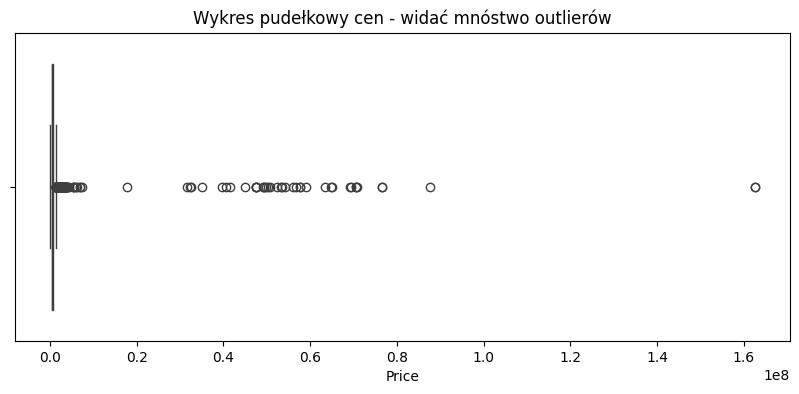

Liczba wykrytych outlierów: 200


In [14]:
# --- ZADANIE 3 ---

plt.figure(figsize=(10, 4))
sns.boxplot(x=otodom['Price'].dropna())
plt.title("Wykres pudełkowy cen - widać mnóstwo outlierów")
plt.show()

Q1 = otodom['Price'].quantile(0.25)
Q3 = otodom['Price'].quantile(0.75)
IQR = Q3 - Q1

dolna_granica = Q1 - 1.5 * IQR
gorna_granica = Q3 + 1.5 * IQR

outlier_data = otodom[(otodom['Price'] < dolna_granica) | (otodom['Price'] > gorna_granica)]

otodom_clean = otodom[(otodom['Price'] >= dolna_granica) & (otodom['Price'] <= gorna_granica)]

print(f"Liczba wykrytych outlierów: {len(outlier_data)}")

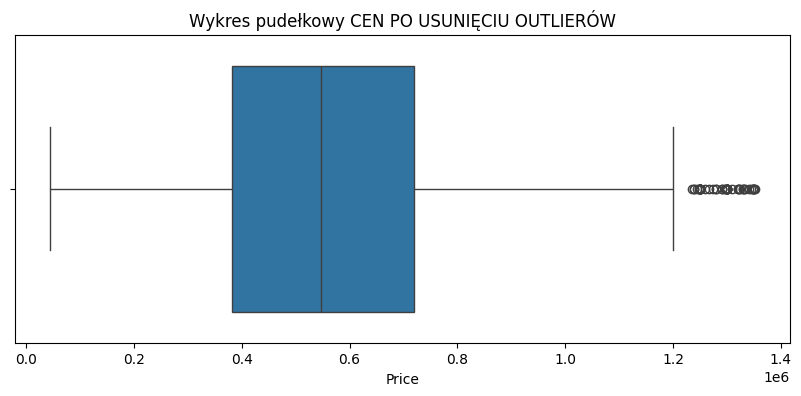

Cena minimalna w czystym zbiorze: 44,444 zł
Cena maksymalna w czystym zbiorze: 1,351,350 zł


In [16]:
# --- SPRAWDZENIE PO CZYSZCZENIU ---

plt.figure(figsize=(10, 4))

sns.boxplot(x=otodom_clean['Price'])
plt.title("Wykres pudełkowy CEN PO USUNIĘCIU OUTLIERÓW")
plt.show()

print(f"Cena minimalna w czystym zbiorze: {otodom_clean['Price'].min():,.0f} zł")
print(f"Cena maksymalna w czystym zbiorze: {otodom_clean['Price'].max():,.0f} zł")

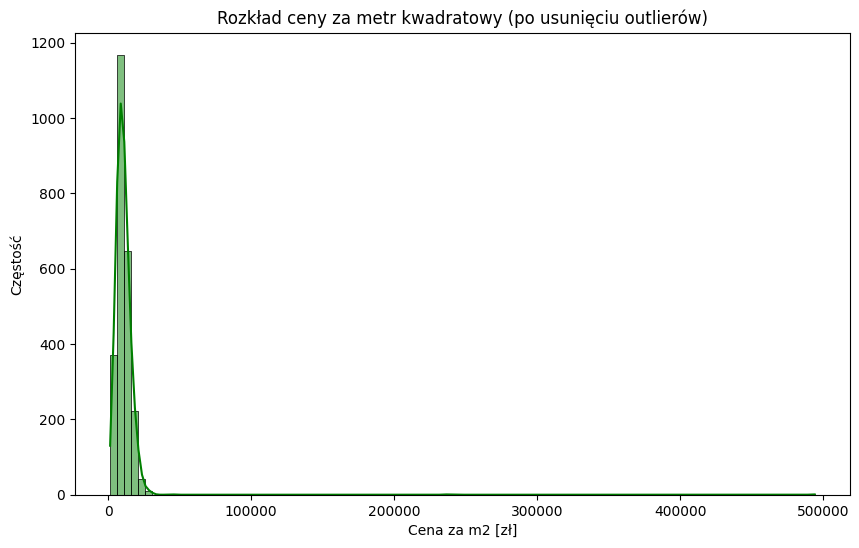

Wartości kwartyli dla ceny za m2:
0.25     7409.930523
0.50     9968.385642
0.75    12910.116633
Name: price_per_m2, dtype: float64


In [18]:
# --- ZADANIE 4 ---


otodom_clean['price_per_m2'] = otodom_clean['Price'] / otodom_clean['Surface']

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(otodom_clean['price_per_m2'].dropna(), kde=True, color='green')

plt.title('Rozkład ceny za metr kwadratowy (po usunięciu outlierów)')
plt.xlabel('Cena za m2 [zł]')
plt.ylabel('Częstość')
plt.show()

kwartyle_m2 = otodom_clean['price_per_m2'].quantile([0.25, 0.5, 0.75])
print("Wartości kwartyli dla ceny za m2:")
print(kwartyle_m2)

Teoretyczne prawdopodobieństwo wyrzucenia dokładnie 7 orłów w 20 rzutach wynosi:
0.0739 (czyli około 7.39%)


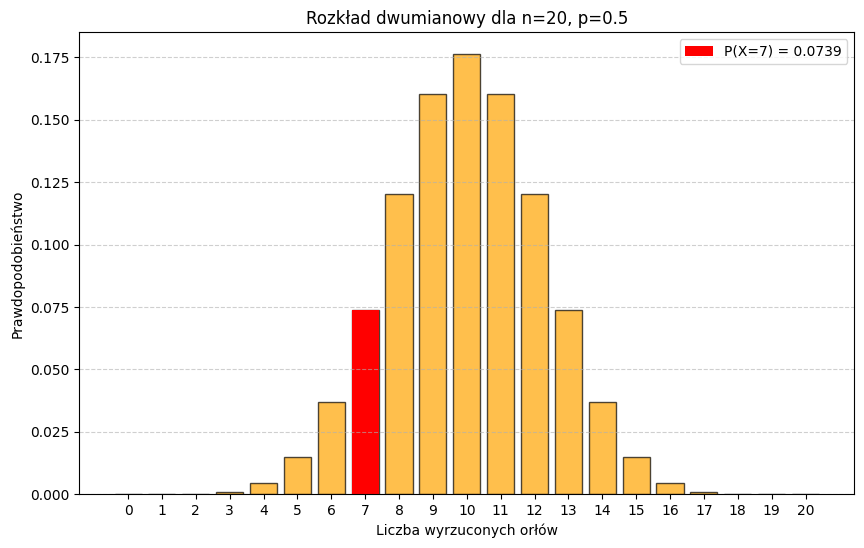

In [20]:
# --- ZADANIE 5 ---
from scipy.stats import binom
import matplotlib.pyplot as plt
import numpy as np

n = 20  # liczba rzutów
p = 0.5 # prawdopodobieństwo sukcesu (uczciwa moneta)
k = 7   # liczba orłów, o którą pytamy

prawdopodobienstwo = binom.pmf(k, n, p)

print(f"Teoretyczne prawdopodobieństwo wyrzucenia dokładnie {k} orłów w {n} rzutach wynosi:")
print(f"{prawdopodobienstwo:.4f} (czyli około {prawdopodobienstwo*100:.2f}%)")

x = np.arange(0, n + 1)
rozklad = binom.pmf(x, n, p)

plt.figure(figsize=(10, 6))
plt.bar(x, rozklad, color='orange', alpha=0.7, edgecolor='black')

plt.bar(k, prawdopodobienstwo, color='red', label=f'P(X=7) = {prawdopodobienstwo:.4f}')

plt.title(f"Rozkład dwumianowy dla n={n}, p={p}")
plt.xlabel("Liczba wyrzuconych orłów")
plt.ylabel("Prawdopodobieństwo")
plt.xticks(x)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

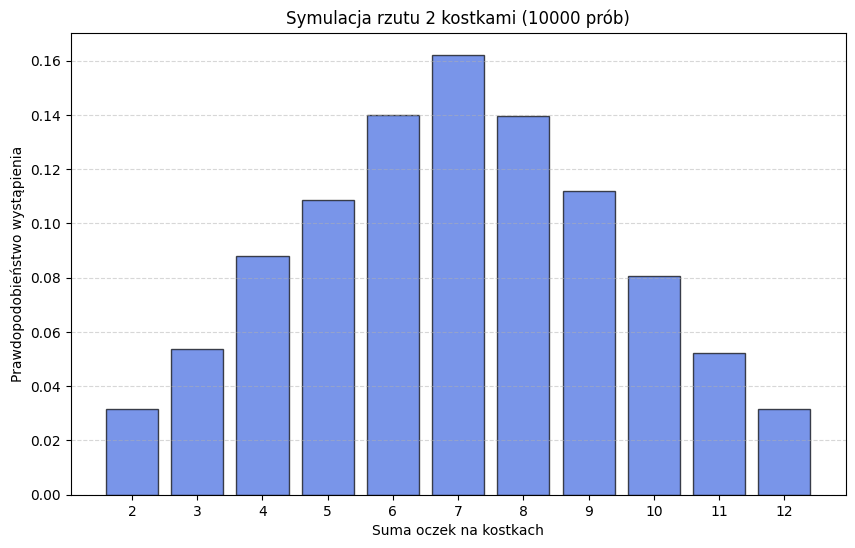

In [22]:
# --- ZADANIE 6 ---


def symulacja_kostek(n_kostek=2, n_prob=10000):


    rzuty = np.random.randint(1, 7, size=(n_prob, n_kostek))
    sumy = rzuty.sum(axis=1)

    plt.figure(figsize=(10, 6))

    bins = np.arange(n_kostek, n_kostek * 6 + 2) - 0.5

    plt.hist(sumy, bins=bins, rwidth=0.8, color='royalblue', alpha=0.7, edgecolor='black', density=True)

    plt.title(f"Symulacja rzutu {n_kostek} kostkami ({n_prob} prób)")
    plt.xlabel("Suma oczek na kostkach")
    plt.ylabel("Prawdopodobieństwo wystąpienia")
    plt.xticks(range(n_kostek, n_kostek * 6 + 1))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

    return sumy

wyniki_symulacji = symulacja_kostek(n_kostek=2, n_prob=10000)